### Code generatiion from a given context


In [464]:
PROJECT_ID = 7954997
MONGODB_DOCUMENT_ID = "68c546bedcdcf56f65e1a4e0"

In [465]:
import os
from dotenv import load_dotenv

load_dotenv()
MONGODB_URI = os.getenv("MONGODB_URI")

In [466]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=os.getenv("AZURE_OPENAI_CHAT_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_CHAT_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT"),
    api_version=os.getenv("AZURE_OPENAI_CHAT_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_CHAT_MODEL_NAME"),
    temperature=0,
)
llm.model_name

'gpt-4.1'

In [467]:
from langchain_openai import AzureOpenAIEmbeddings

embeddings = AzureOpenAIEmbeddings(
    api_key=os.getenv("AZURE_OPENAI_EMBEDDING_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_EMBEDDING_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT"),
    api_version=os.getenv("AZURE_OPENAI_EMBEDDING_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_EMBEDDING_MODEL_NAME"),
)
embeddings.model

'text-embedding-3-large'

In [468]:
import tiktoken


def number_of_tokens(
    input: str,
    debug_message: str,
    encoding_name: str = "cl100k_base",
) -> int:
    """Returns the number of tokens in a input string"""

    print(f"--------------\nDebug Message\n--------------\n{debug_message}")

    encoding = tiktoken.get_encoding(encoding_name=encoding_name)
    num_tokens = len(encoding.encode(input))
    print(f"Total number of tokens: {num_tokens}")
    return num_tokens

In [469]:
number_of_tokens(input="Hello World", debug_message="Test debug message")

--------------
Debug Message
--------------
Test debug message
Total number of tokens: 2


2

In [470]:
from pymongo import MongoClient

client = MongoClient(MONGODB_URI)
print(client.server_info())

print("Connected to Mongo DB")

collection = client["opensolar_db"]["project"]
print(collection)

{'version': '8.0.15', 'gitVersion': 'f79b970f08f60c41491003cd55a3dd459a279c39', 'modules': ['enterprise'], 'allocator': 'tcmalloc-google', 'javascriptEngine': 'mozjs', 'sysInfo': 'deprecated', 'versionArray': [8, 0, 15, 0], 'bits': 64, 'debug': False, 'maxBsonObjectSize': 16777216, 'storageEngines': ['devnull', 'inMemory', 'queryable_wt', 'wiredTiger'], 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1760726139, 1), 'signature': {'hash': b'\x99\x9dxN0O@\xc6\x11%rn\x8c\x16d\xecT\x8e\xc3\n', 'keyId': 7500256948978188295}}, 'operationTime': Timestamp(1760726139, 1)}
Connected to Mongo DB
Collection(Database(MongoClient(host=['ac-pd9xhlm-shard-00-02.jmdonyw.mongodb.net:27017', 'ac-pd9xhlm-shard-00-01.jmdonyw.mongodb.net:27017', 'ac-pd9xhlm-shard-00-00.jmdonyw.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, authsource='admin', replicaset='atlas-11s7i4-shard-0', tls=True), 'opensolar_db'), 'project')


{'access': 2, 'events': ['https://api.opensolar.com/api/orgs/178878/events/39879463/', 'https://api.opensolar.com/api/orgs/178878/events/39880151/', 'https://api.opensolar.com/api/orgs/178878/events/39880156/', 'https://api.opensolar.com/api/orgs/178878/events/40198325/', 'https://api.opensolar.com/api/orgs/178878/events/40198333/', 'https://api.opensolar.com/api/orgs/178878/events/40198363/', 'https://api.opensolar.com/api/orgs/178878/events/40198366/', 'https://api.opensolar.com/api/orgs/178878/events/40198374/', 'https://api.opensolar.com/api/orgs/178878/events/40198384/', 'https://api.opensolar.com/api/orgs/178878/events/40198400/', 'https://api.opensolar.com/api/orgs/178878/events/40198401/', 'https://api.opensolar.com/api/orgs/178878/events/40198404/', 'https://api.opensolar.com/api/orgs/178878/events/40198407/', 'https://api.opensolar.com/api/orgs/178878/events/40198416/', 'https://api.opensolar.com/api/orgs/178878/events/40198419/', 'https://api.opensolar.com/api/orgs/178878/ev
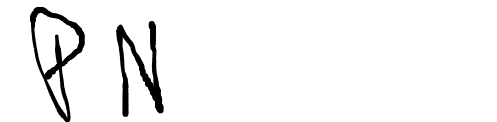

In [471]:
from bson import ObjectId


mongo_doc = collection.find_one({"_id": ObjectId(MONGODB_DOCUMENT_ID)}, {"_id": 0})
print(mongo_doc, sep="\n")

In [472]:
# json preprocessing

for k, v in mongo_doc.items():
    if k == "design":
        print(k, "Found")
        mongo_doc[k] = "Design Exists"
    elif k == "transactions_data":
        print(k, "Found")
        mongo_doc[k][0]["signature_data"] = "Signature Data Exists"
        # del mongo_doc[v[0]["signature_data"]]

design Found
transactions_data Found


In [473]:
from typing import List
from langchain.schema import Document

documents: List[Document] = []

In [474]:
import json

for k, v in mongo_doc.items():
    documents.append(Document(page_content=json.dumps(v), metadata={"keys": k}))

documents

[Document(metadata={'keys': 'access'}, page_content='2'),
 Document(metadata={'keys': 'events'}, page_content='["https://api.opensolar.com/api/orgs/178878/events/39879463/", "https://api.opensolar.com/api/orgs/178878/events/39880151/", "https://api.opensolar.com/api/orgs/178878/events/39880156/", "https://api.opensolar.com/api/orgs/178878/events/40198325/", "https://api.opensolar.com/api/orgs/178878/events/40198333/", "https://api.opensolar.com/api/orgs/178878/events/40198363/", "https://api.opensolar.com/api/orgs/178878/events/40198366/", "https://api.opensolar.com/api/orgs/178878/events/40198374/", "https://api.opensolar.com/api/orgs/178878/events/40198384/", "https://api.opensolar.com/api/orgs/178878/events/40198400/", "https://api.opensolar.com/api/orgs/178878/events/40198401/", "https://api.opensolar.com/api/orgs/178878/events/40198404/", "https://api.opensolar.com/api/orgs/178878/events/40198407/", "https://api.opensolar.com/api/orgs/178878/events/40198416/", "https://api.opensol

In [475]:
import json
doc = json.dumps(mongo_doc, ensure_ascii=True)

with open("../data/doc.txt", "w") as f:
    f.write(doc)

In [476]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

chunks = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, separators=["\n", "\n\n", " ", ""]
).split_documents(documents=documents)

In [477]:
from langchain.vectorstores import Chroma

retriever = Chroma.from_documents(documents=chunks, embedding=embeddings).as_retriever(
    search_type="similarity"
)

retriever

VectorStoreRetriever(tags=['Chroma', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000233B4F2FAD0>, search_kwargs={})

In [478]:
from typing import List


def format_chunks(chunks: List[str]) -> str:
    return "\n\n".join(chunk for chunk in chunks)

In [479]:
from langchain.prompts import ChatPromptTemplate

template = """Act as a Senior Solution Architect with 10 plus years of experience.

Here is your context: {context}

Currently, your job is to design a relational database schema from a JSON for a Solar Energy Project. 
The relational database is PostgreSQL. Provide the full in-depth SQL script.
Make sure you do not skip any line or key value pair in the JSON data

Here is the JSON DATA:
{json_data}
"""

schema_generation_prompt = ChatPromptTemplate.from_template(template=template)
schema_generation_prompt

ChatPromptTemplate(input_variables=['context', 'json_data'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'json_data'], input_types={}, partial_variables={}, template='Act as a Senior Solution Architect with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to design a relational database schema from a JSON for a Solar Energy Project. \nThe relational database is PostgreSQL. Provide the full in-depth SQL script.\nMake sure you do not skip any line or key value pair in the JSON data\n\nHere is the JSON DATA:\n{json_data}\n'), additional_kwargs={})])

In [480]:
template = """Act as a Senior Software Engineer with 10 plus years of experience.

Here is your context: {context}

Currently, your job is to write a complete Python script using Peewee (PostgreSQL ORM) for Data ingestion.
Refer to the provided DB Schema as an input. Make sure you do not any of the table present in the provided DB Schema.

Here is the DB Schema:
{db_schema}
"""

code_generation_prompt = ChatPromptTemplate.from_template(template=template)
code_generation_prompt

ChatPromptTemplate(input_variables=['context', 'db_schema'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'db_schema'], input_types={}, partial_variables={}, template='Act as a Senior Software Engineer with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to write a complete Python script using Peewee (PostgreSQL ORM) for Data ingestion.\nRefer to the provided DB Schema as an input. Make sure you do not any of the table present in the provided DB Schema.\n\nHere is the DB Schema:\n{db_schema}\n'), additional_kwargs={})])

In [481]:
template = """Act as a Senior Software Engineer with 10 plus years of experience.

Here is your context: {context}

Currently, your job is to review the provided Python code generated by other developers.
The Python code is about inserting data into a PostgrSQL database using Peewee. 
You will be provided with a DB Schema and Python Code.

You will check both the DB Schema and the Python Code line by line parallelly.
Respond only in YES or NO. If the Python code is perfect, then return YES; else return NO.

Here is the DB Schema: {db_schema}

Here is the Python Code: {generated_code}
"""

code_validation_prompt = ChatPromptTemplate.from_template(template=template)
code_validation_prompt

ChatPromptTemplate(input_variables=['context', 'db_schema', 'generated_code'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'db_schema', 'generated_code'], input_types={}, partial_variables={}, template='Act as a Senior Software Engineer with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to review the provided Python code generated by other developers.\nThe Python code is about inserting data into a PostgrSQL database using Peewee. \nYou will be provided with a DB Schema and Python Code.\n\nYou will check both the DB Schema and the Python Code line by line parallelly.\nRespond only in YES or NO. If the Python code is perfect, then return YES; else return NO.\n\nHere is the DB Schema: {db_schema}\n\nHere is the Python Code: {generated_code}\n'), additional_kwargs={})])

In [482]:
from typing import Literal

from pydantic import BaseModel, Field


class GenerateDBSchema(BaseModel):
    db_schema: str


class GeneratePythonCode(BaseModel):
    python_code: str


class ValidatePythonCode(BaseModel):
    is_code_correct: Literal["YES", "NO"] = Field(
        description="Returns YES if code is perfect, else NO"
    )

In [483]:
from langchain_core.runnables import RunnableLambda, RunnableMap, RunnablePassthrough

json_string_runnable = RunnablePassthrough() | RunnableLambda(
    lambda x: json.dumps(x, ensure_ascii=True)
)

schema_generation_chain = (
    RunnableMap({"context": retriever, "json_data": json_string_runnable})
    | schema_generation_prompt
    | llm.with_structured_output(GenerateDBSchema)
)
schema_generation_chain

{
  context: VectorStoreRetriever(tags=['Chroma', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000233B4F2FAD0>, search_kwargs={}),
  json_data: RunnablePassthrough()
             | RunnableLambda(lambda x: json.dumps(x, ensure_ascii=True))
}
| ChatPromptTemplate(input_variables=['context', 'json_data'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'json_data'], input_types={}, partial_variables={}, template='Act as a Senior Solution Architect with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to design a relational database schema from a JSON for a Solar Energy Project. \nThe relational database is PostgreSQL. Provide the full in-depth SQL script.\nMake sure you do not skip any line or key value pair in the JSON data\n\nHere is the JSON DATA:\n{json_data}\n'), additional_kwargs={})])
| RunnableBinding(bound=Az

In [484]:
code_generation_chain = (
    {
        "context": retriever,
        "db_schema": RunnablePassthrough(),
    }
    | code_generation_prompt
    | llm.with_structured_output(GeneratePythonCode)
)
code_generation_chain

{
  context: VectorStoreRetriever(tags=['Chroma', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000233B4F2FAD0>, search_kwargs={}),
  db_schema: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'db_schema'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'db_schema'], input_types={}, partial_variables={}, template='Act as a Senior Software Engineer with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to write a complete Python script using Peewee (PostgreSQL ORM) for Data ingestion.\nRefer to the provided DB Schema as an input. Make sure you do not any of the table present in the provided DB Schema.\n\nHere is the DB Schema:\n{db_schema}\n'), additional_kwargs={})])
| RunnableBinding(bound=AzureChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000233C

In [485]:
code_validation_chain = (
    {
        "context": retriever,
        "generated_code": RunnablePassthrough(),
        "db_schema": RunnablePassthrough(),
    }
    | code_validation_prompt
    | llm.with_structured_output(ValidatePythonCode)
)

code_validation_chain

{
  context: VectorStoreRetriever(tags=['Chroma', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000233B4F2FAD0>, search_kwargs={}),
  generated_code: RunnablePassthrough(),
  db_schema: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'db_schema', 'generated_code'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'db_schema', 'generated_code'], input_types={}, partial_variables={}, template='Act as a Senior Software Engineer with 10 plus years of experience.\n\nHere is your context: {context}\n\nCurrently, your job is to review the provided Python code generated by other developers.\nThe Python code is about inserting data into a PostgrSQL database using Peewee. \nYou will be provided with a DB Schema and Python Code.\n\nYou will check both the DB Schema and the Python Code line by line parallelly.\nRespond only in YES or NO. If the 

In [486]:
type(doc)

str

In [487]:
# from langchain.chains.combine_documents import create_stuff_documents_chain
# from langchain.chains.retrieval import create_retrieval_chain

# chain = create_retrieval_chain(
#     retriever=retriever,
#     combine_docs_chain=create_stuff_documents_chain(
#         llm=llm, prompt=code_generation_prompt
#     ),
# )

# chain

In [488]:
from typing import Optional

from typing_extensions import TypedDict


class State(TypedDict):
    json_data: str = doc
    db_schema: Optional[str] = None
    generated_code: Optional[str] = None

In [489]:
from langgraph.graph import END, START, StateGraph

In [490]:
def generate_db_schema(state: State):
    """Iterate over JSON chunks and generate schema per chunk."""

    print(f"Present Node: {generate_db_schema.__name__}")

    number_of_tokens(input=state["json_data"], debug_message="Tokens of JSON Data")

    print(f"Type of json data {type(state["json_data"])}")

    res: GenerateDBSchema = schema_generation_chain.invoke(
        {"json_data": state["json_data"]}
    )
    print(f"Response: {res.db_schema}")

    return {"db_schema": res.db_schema}

In [491]:
def generate_python_code(state: State):
    """Generate Python Code from the provided DB Schema and the JSON chunk"""

    print(f"Present Node: {generate_python_code.__name__}")

    number_of_tokens(input=state["db_schema"], debug_message="Tokens of DB Schema")

    res: GeneratePythonCode = code_generation_chain.invoke(
        {"context": state["json_data"], "db_schema": state["db_schema"]}
    )
    print(f"Response: {res.python_code}")
    return {"generated_code": res.python_code}

In [492]:
def review_generated_code(state: State):
    """Validates the Python code generated from DB Schema"""

    print(f"Present Node: {review_generated_code.__name__}")

    dbs_tokens = number_of_tokens(
        input=state["db_schema"], debug_message="Tokens of DB Schema"
    )

    pycode_tokens = number_of_tokens(
        input=state["generated_code"], debug_message="Tokens of generated Python Code"
    )
    print(f"Total Tokens: {dbs_tokens + pycode_tokens}")

    res: ValidatePythonCode = code_validation_chain.invoke(
        {
            "context": state["json_data"],
            "generated_code": state["generated_code"],
            "db_schema": state["db_schema"],
        }
    )
    print(f"Response: {res.is_code_correct}")

    return "successful" if res.is_code_correct == "YES" else "failed"

In [493]:
builder = StateGraph(State)

builder.add_node("db_schema", generate_db_schema)
builder.add_node("code_generation", generate_python_code)


builder.add_edge(START, "db_schema")
builder.add_edge("db_schema", "code_generation")
builder.add_conditional_edges(
    "code_generation",
    review_generated_code,
    {"successful": END, "failed": "code_generation"},
)

graph = builder.compile()

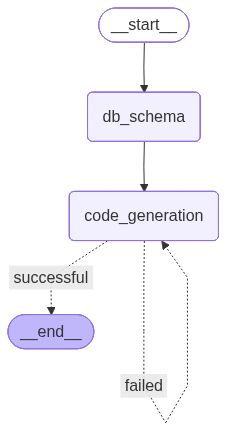

In [494]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [495]:
type(doc)

str

In [496]:
print(all(isinstance(c, str) for c in chunks))

False


In [497]:
state = {"json_data": doc}

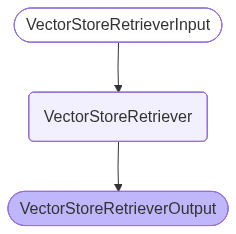

In [498]:
display(Image(retriever.get_graph().draw_mermaid_png()))

In [499]:
retriever.invoke(doc)

[Document(metadata={}, page_content='[], "event_icon": 3}, {"id": 40198333, "org": "https://api.opensolar.com/api/orgs/178878/", "project_id": 7954997, "duration": 0, "event_type_id": 32, "action_id": 1996457, "start": "2025-09-12 08:09:53.133070+00:00", "end": "2025-09-12T08:09:53.133075Z", "created_date": "2025-09-12T08:09:53.145094Z", "modified_date": "2025-09-12T08:09:53.145109Z", "who": {"display": "Pritis Nayak", "email": "pritis@aoplenergy.com", "portrait_image_public_url": null}, "notify_team_members": [], "completion_date": "2025-09-12 08:09:53.133075+00:00", "title": "Send Proposal to Customer", "project_name": "my test address line 1.0 my test address line 2.0", "is_planned": false, "task_status": 0, "is_complete": true, "notes": null, "is_archived": false, "categories": [0, 7], "form_config": 4, "team_members": [], "event_icon": 3}, {"id": 40198325, "org": "https://api.opensolar.com/api/orgs/178878/", "project_id": 7954997, "duration": 0, "event_type_id": 32, "action_id": 1

In [500]:
res = graph.invoke(state)

Present Node: generate_db_schema
--------------
Debug Message
--------------
Tokens of JSON Data
Total number of tokens: 34305
Type of json data <class 'str'>


TypeError: argument 'text': 'dict' object cannot be converted to 'PyString'

In [ ]:
for document in documents:
    print(document.page_content)

2
["https://api.opensolar.com/api/orgs/178878/events/39879463/", "https://api.opensolar.com/api/orgs/178878/events/39880151/", "https://api.opensolar.com/api/orgs/178878/events/39880156/", "https://api.opensolar.com/api/orgs/178878/events/40198325/", "https://api.opensolar.com/api/orgs/178878/events/40198333/", "https://api.opensolar.com/api/orgs/178878/events/40198363/", "https://api.opensolar.com/api/orgs/178878/events/40198366/", "https://api.opensolar.com/api/orgs/178878/events/40198374/", "https://api.opensolar.com/api/orgs/178878/events/40198384/", "https://api.opensolar.com/api/orgs/178878/events/40198400/", "https://api.opensolar.com/api/orgs/178878/events/40198401/", "https://api.opensolar.com/api/orgs/178878/events/40198404/", "https://api.opensolar.com/api/orgs/178878/events/40198407/", "https://api.opensolar.com/api/orgs/178878/events/40198416/", "https://api.opensolar.com/api/orgs/178878/events/40198419/", "https://api.opensolar.com/api/orgs/178878/events/40198420/", "http

In [505]:
dicts = []
lists = []
strs = []
others = []

In [506]:
for k, v in mongo_doc.items():
    if isinstance(v, dict):
        dicts.append(k)
    elif isinstance(v, list):
        lists.append(k)
    elif isinstance(v, str):
        strs.append(k)
    else:
        others.append(k)

In [507]:
print(len(dicts))
print(len(lists))
print(len(strs))
print(len(others))

10
23
61
54


In [508]:
others

['access',
 'assigned_role_id',
 'assigned_installer_role_data',
 'assigned_installer_role',
 'assigned_site_inspector_role_data',
 'assigned_site_inspector_role',
 'assigned_designer_role_id',
 'assigned_salesperson_role_id',
 'business_name',
 'configuration_override',
 'costing_override',
 'contract',
 'county',
 'greenlancer_project_id',
 'id',
 'is_residential',
 'is_pricing_locked',
 'language_override',
 'last_calculation_error',
 'lat',
 'lon',
 'number_of_phases',
 'number_of_wires',
 'number_of_storeys',
 'original_system_sold',
 'org_id',
 'priority',
 'project_installed',
 'project_sold',
 'proposal_template',
 'simulate_first_year_only',
 'stage',
 'system_installed',
 'temperature_max_override',
 'temperature_min_override',
 'timezone_offset',
 'usage_annual_or_guess',
 'usage',
 'utility_tariff_current_data',
 'utility_tariff_current',
 'utility_tariff_proposed_data',
 'utility_tariff_proposed',
 'wind_region',
 'has_cellular_coverage',
 'federal_income_tax_rate_percenta

In [510]:
for k, v in mongo_doc.items():
    if k in others:
        print({k: v})

{'access': 2}
{'assigned_role_id': 349506}
{'assigned_installer_role_data': None}
{'assigned_installer_role': None}
{'assigned_site_inspector_role_data': None}
{'assigned_site_inspector_role': None}
{'assigned_designer_role_id': 349506}
{'assigned_salesperson_role_id': 317791}
{'business_name': None}
{'configuration_override': None}
{'costing_override': None}
{'contract': None}
{'county': None}
{'greenlancer_project_id': None}
{'id': 7954997}
{'is_residential': True}
{'is_pricing_locked': True}
{'language_override': None}
{'last_calculation_error': None}
{'lat': 12.9554}
{'lon': 77.6534}
{'number_of_phases': 3}
{'number_of_wires': None}
{'number_of_storeys': None}
{'original_system_sold': None}
{'org_id': 178878}
{'priority': 3}
{'project_installed': 1}
{'project_sold': 2}
{'proposal_template': None}
{'simulate_first_year_only': False}
{'stage': 0}
{'system_installed': None}
{'temperature_max_override': None}
{'temperature_min_override': None}
{'timezone_offset': 5.5}
{'usage_annual_or